In [67]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### TEST FINALE :(
    

In [68]:
# 1. Librerie per la manipolazione e l'analisi dei dati
import pandas as pd
import numpy as np

# 2. Librerie per i grafici e la visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Componenti specifici di Scikit-Learn per l'IA (Machine Learning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

### ANALISI ESPLORATIVA

#### CARICAMENTO DATI ED INFORMAZIONI SUL DATASET

In [69]:
df = pd.read_csv('music_genre.csv')  
df.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [70]:
print("Dimensioni iniziali del dataset:")
print(df.shape)
df.info()


Dimensioni iniziali del dataset:
(50005, 18)
<class 'pandas.DataFrame'>
RangeIndex: 50005 entries, 0 to 50004
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       50000 non-null  float64
 1   artist_name       50000 non-null  str    
 2   track_name        50000 non-null  str    
 3   popularity        50000 non-null  float64
 4   acousticness      50000 non-null  float64
 5   danceability      50000 non-null  float64
 6   duration_ms       50000 non-null  float64
 7   energy            50000 non-null  float64
 8   instrumentalness  50000 non-null  float64
 9   key               50000 non-null  str    
 10  liveness          50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  mode              50000 non-null  str    
 13  speechiness       50000 non-null  float64
 14  tempo             50000 non-null  str    
 15  obtained_date     50000 non-null  str    
 16  valenc

In [71]:
print("\nValori mancanti per colonna:")
display(df.isnull().sum())


Valori mancanti per colonna:


instance_id         5
artist_name         5
track_name          5
popularity          5
acousticness        5
danceability        5
duration_ms         5
energy              5
instrumentalness    5
key                 5
liveness            5
loudness            5
mode                5
speechiness         5
tempo               5
obtained_date       5
valence             5
music_genre         5
dtype: int64

#### PULIZIA DATI

In [72]:
# Sostituiamo i valori mancanti rappresentati da "?" con NaN.
df.replace("?", np.nan, inplace=True)

# Convertiamo forzatamente in formato numerico decimale (float).
df["tempo"] = pd.to_numeric(df["tempo"])

# Rimuoviamo le righe con valori mancanti
df.dropna(inplace=True)

# Rimuoviamo eventuali righe identiche salvate per errore nel file CSV per non falsare i modelli.
df.drop_duplicates(inplace=True)

# 'instance_id': un semplice indice numerico del database senza valore musicale.
# 'obtained_date': la data di scaricamento dei dati , inutile per gli obiettivi del progetto.

colonne_inutili = ["instance_id", "obtained_date"]

# Eseguiamo la rimozione fisica dal dataset
df.drop(columns=colonne_inutili, inplace=True)

df.head()


,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,0.759,Electronic
1,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.002,0.531,Electronic
2,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
3,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
4,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic


##### Sono stati sostituiti i punti interrogativi con valori NaN.
##### La colonna tempo è stata convertita in numerica.
##### Sono state eliminate righe con valori mancanti e duplicati.
##### Le colonne instance_id e obtained_date sono state rimosse perché non utili alla classificazione musicale.

#### GRAFICI INIZIALI


##### STILE GRAFICI


In [73]:
sns.set_theme(style="whitegrid", context="notebook")

colore_viola = "#6C63FF"
colore_rosso = "#FF6B6B"
colore_verde = "#4ECDC4"
colore_giallo = "#6A4B03"
colore_blu = "#118AB2"

##### DISTRIBUZIONE GENERI MUSICALI

C:\Users\Antonella\AppData\Local\Temp\ipykernel_34304\5340539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


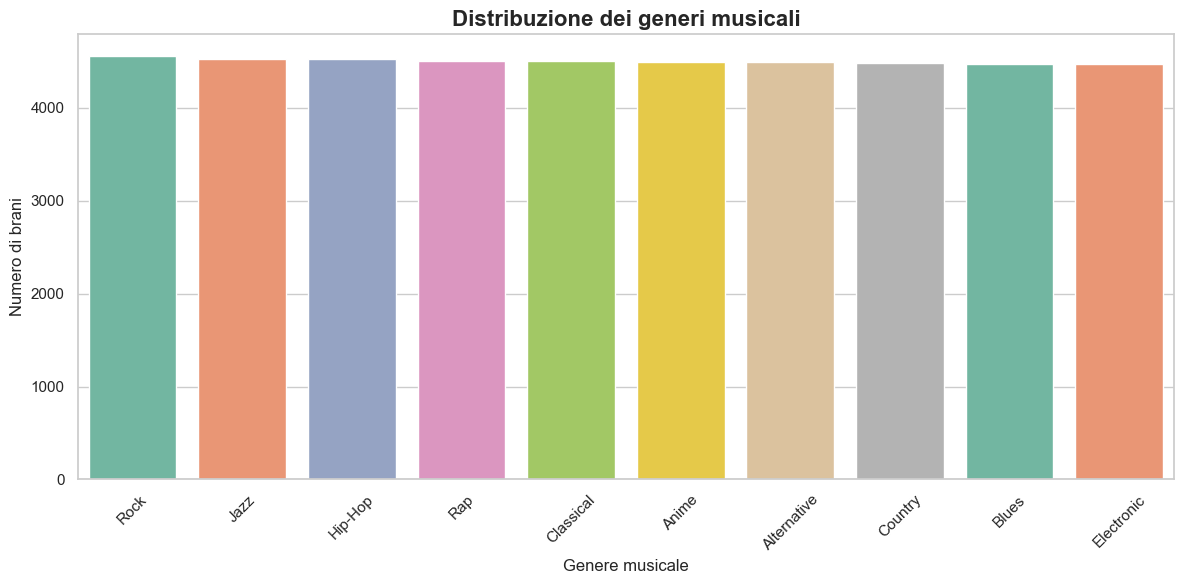

In [74]:
plt.figure(figsize=(12, 6))

ordine_generi = df["music_genre"].value_counts().index
palette_generi = sns.color_palette("Set2", n_colors=df["music_genre"].nunique())

sns.countplot(
    data=df,
    x="music_genre",
    order=ordine_generi,
    palette=palette_generi
)

plt.title("Distribuzione dei generi musicali", fontsize=16, fontweight="bold")
plt.xlabel("Genere musicale")
plt.ylabel("Numero di brani")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### I generi musicali risultano abbastanza bilanciati. 
##### Questo è positivo perché il modello non viene troppo influenzato da un genere molto più presente degli altri.


##### POPULARITY

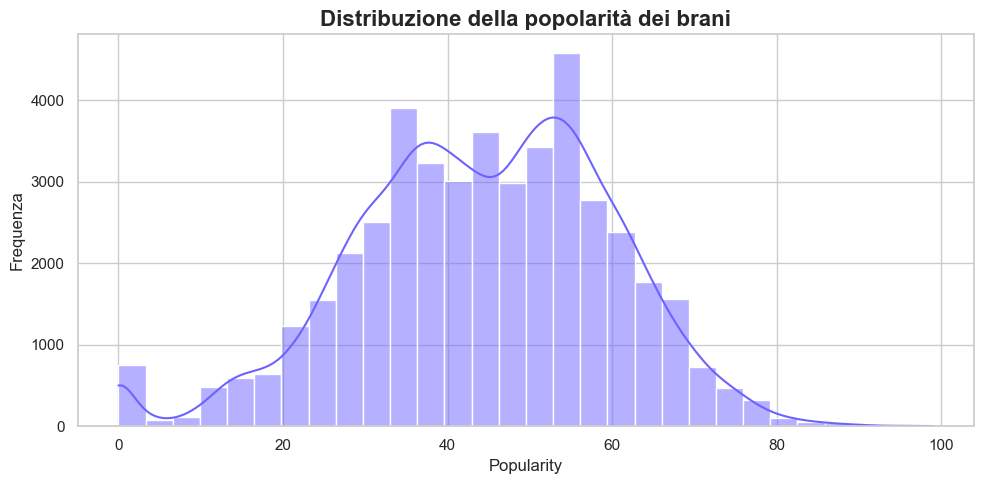

In [75]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["popularity"],
    bins=30,
    kde=True,
    color=colore_viola
)

plt.title("Distribuzione della popolarità dei brani", fontsize=16, fontweight="bold")
plt.xlabel("Popularity")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

##### Molti brani hanno una popolarità medio-bassa.
##### Sono meno frequenti i brani con valori di popolarità molto alti.

#### ENERGY

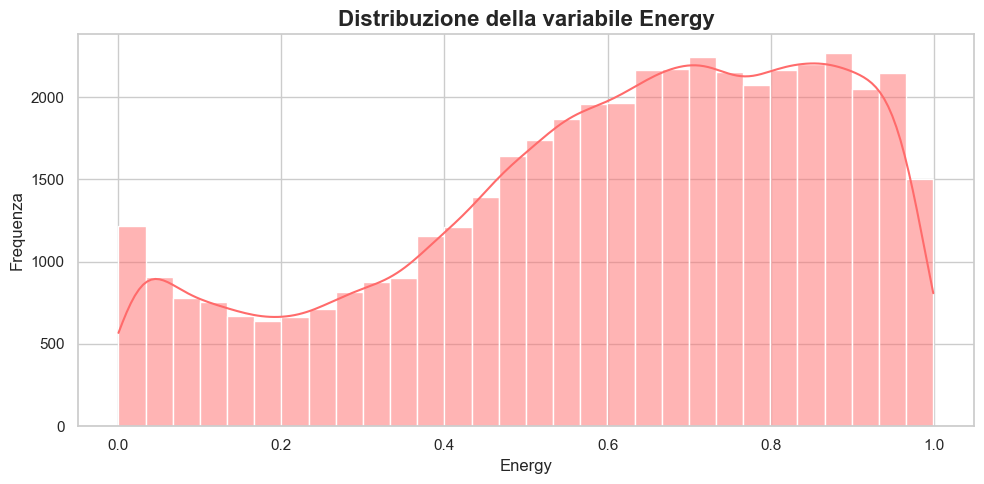

In [76]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["energy"],
    bins=30,
    kde=True,
    color=colore_rosso
)

plt.title("Distribuzione della variabile Energy", fontsize=16, fontweight="bold")
plt.xlabel("Energy")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

##### Molti brani presentano valori medio-alti di energy.
##### Questa variabile può essere utile per distinguere generi più intensi da generi più tranquilli.


##### DANCEABILITY

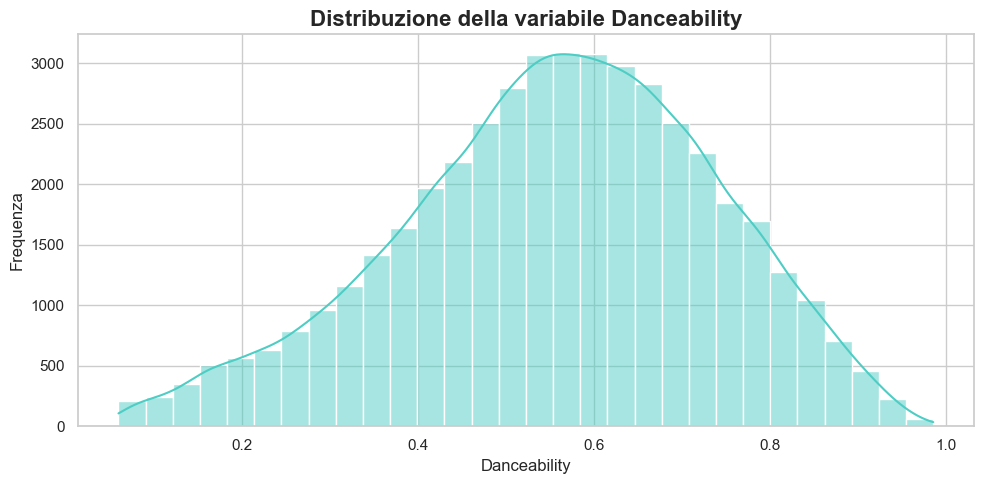

In [77]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["danceability"],
    bins=30,
    kde=True,
    color=colore_verde
)

plt.title("Distribuzione della variabile Danceability", fontsize=16, fontweight="bold")
plt.xlabel("Danceability")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

##### La danceability si concentra soprattutto su valori intermedi.
##### Può aiutare a distinguere generi più ballabili da generi meno ritmici.

##### ACOUSTICNESS


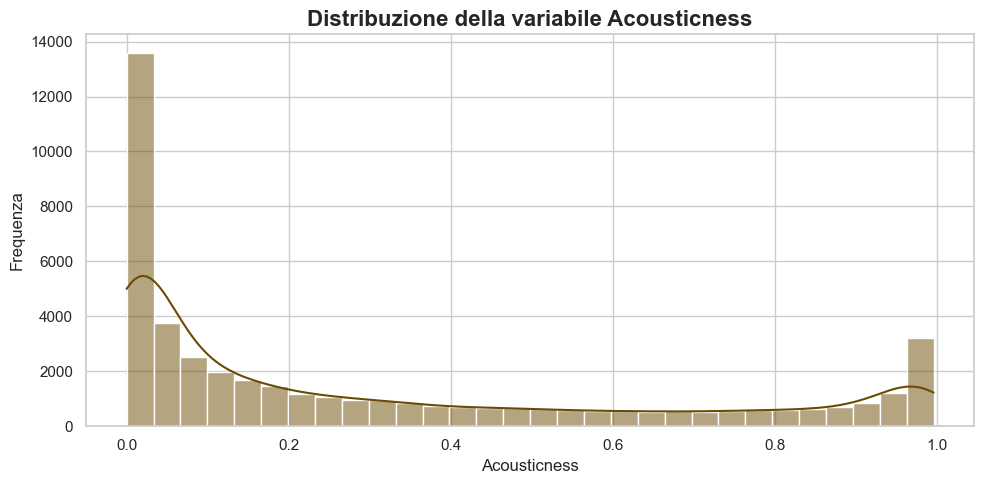

In [78]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["acousticness"],
    bins=30,
    kde=True,
    color=colore_giallo
)

plt.title("Distribuzione della variabile Acousticness", fontsize=16, fontweight="bold")
plt.xlabel("Acousticness")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

##### Molti brani hanno valori bassi di acousticness.
##### Questo indica che diversi brani sono poco acustici e più legati a suoni prodotti o elettronici.

##### HEATMAP CORRELAZIONI

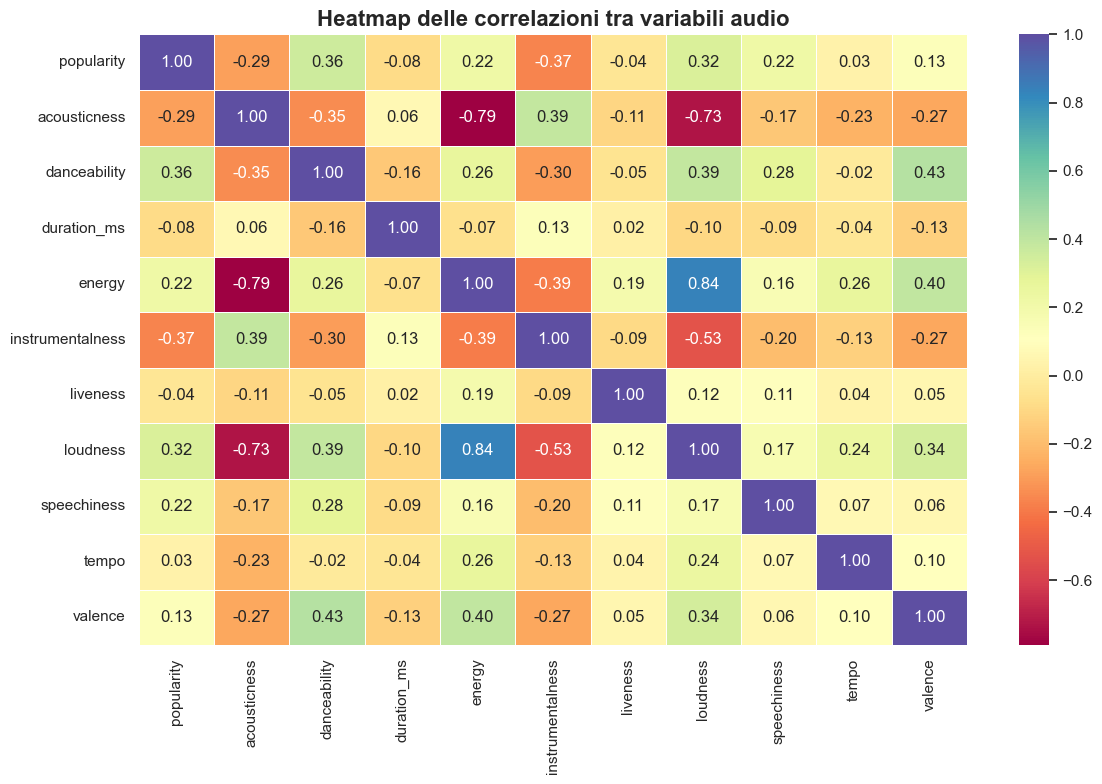

In [79]:
colonne_numeriche = [
    "popularity",
    "acousticness",
    "danceability",
    "duration_ms",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[colonne_numeriche].corr(),
    annot=True,
    cmap="Spectral",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap delle correlazioni tra variabili audio", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

##### Energy e loudness risultano collegate tra loro.
##### Questo è coerente perché i brani più energici tendono spesso ad avere anche un volume percepito più alto.

#### STATISTICHE INIZIALI DOPO LA PULIZIA DEI DATI

In [80]:
print("Statistiche descrittive:")
display(df.describe())

print("Distribuzione dei generi musicali:")
display(df["music_genre"].value_counts())


Statistiche descrittive:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,45020.000000,45020.000000,45020.000000,4.502000e+04,45020.000000,45020.000000,45020.000000,45020.000000,45020.000000,45020.000000,45020.000000
mean,44.263327,0.306596,0.558532,2.211695e+05,0.599553,0.181843,0.193951,-9.137016,0.093783,119.952961,0.456394
std,15.553972,0.341391,0.178858,1.276884e+05,0.264510,0.325847,0.161715,6.156400,0.101469,30.641701,0.247161
min,0.000000,0.000000,0.059600,-1.000000e+00,0.000792,0.000000,0.009670,-47.046000,0.022300,34.347000,0.000000
25%,34.000000,0.020100,0.442000,1.747230e+05,0.432000,0.000000,0.096900,-10.860000,0.036100,94.941500,0.257000
50%,45.000000,0.145000,0.568000,2.194385e+05,0.642000,0.000159,0.126000,-7.284000,0.048900,119.879000,0.448000
75%,56.000000,0.551000,0.687000,2.686400e+05,0.815250,0.154000,0.244000,-5.177000,0.098800,140.471250,0.648000
max,99.000000,0.996000,0.986000,4.497994e+06,0.999000,0.996000,1.000000,3.744000,0.942000,220.276000,0.992000


Distribuzione dei generi musicali:


music_genre
Rock           4561
Jazz           4521
Hip-Hop        4520
Rap            4504
Classical      4500
Anime          4497
Alternative    4495
Country        4486
Blues          4470
Electronic     4466
Name: count, dtype: int64

#### GRAFICO STATISTICHE INIZIALI

#### BOXPLOT

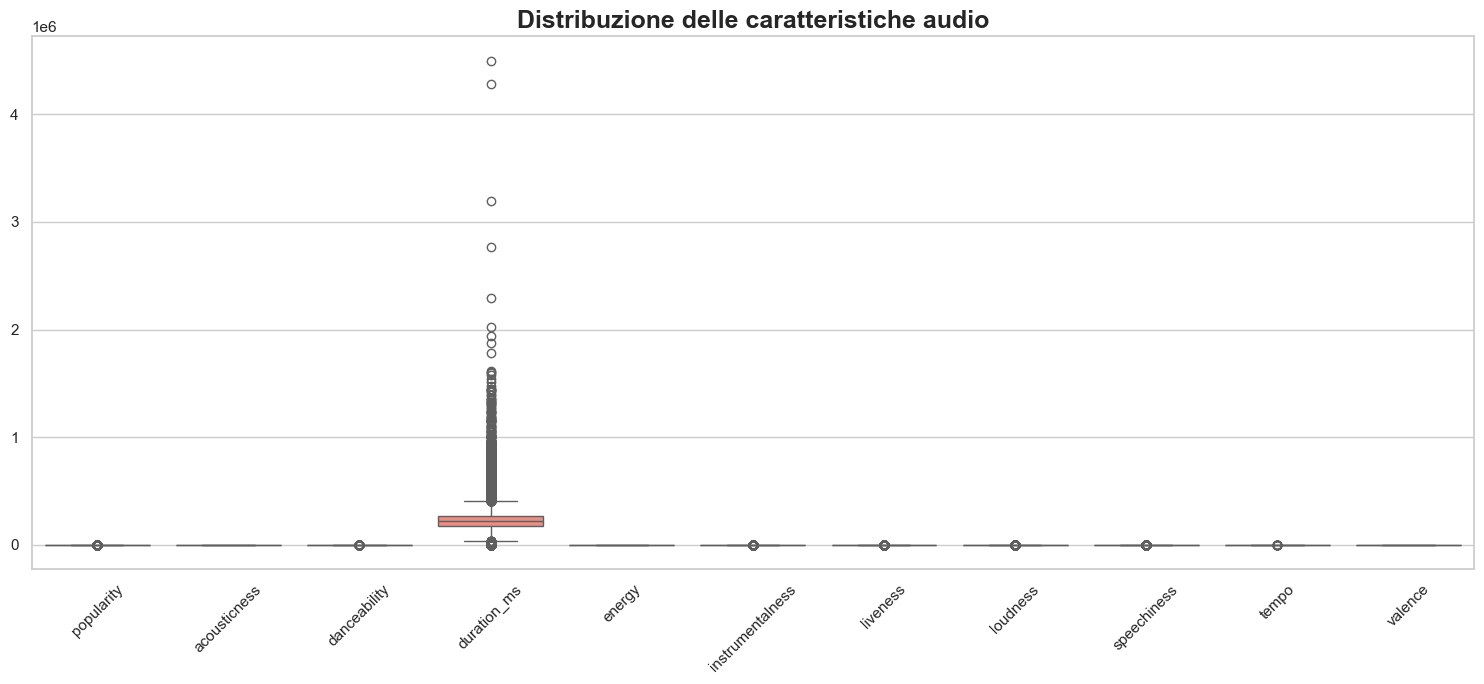

In [82]:
plt.figure(figsize=(15,7))

sns.boxplot(
    data=df[colonne_numeriche],
    palette="Set3"
)

plt.title(
    "Distribuzione delle caratteristiche audio",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Il boxplot evidenzia la presenza di differenti distribuzioni tra le variabili audio. Alcune caratteristiche presentano una dispersione elevata e numerosi outlier, suggerendo una forte eterogeneità tra i brani. Questo potrebbe favorire la capacità dei modelli di distinguere i generi musicali.